# 1. Condition Classification

In [ ]:
%load_ext cuml.accel

import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
from scipy import sparse

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    roc_auc_score, average_precision_score,
    classification_report, roc_curve, precision_recall_curve
)

RANDOM_STATE = 1

import warnings
warnings.filterwarnings("ignore")

## 1.1. Treatment Classification
**Task**: Classify which treatment condition (IFNγ vs Co-culture vs Control) a cell came from using the cells gene 
expression profile (no additional features).

IFNγ: Treated with IFNγ \
Co-culture: Co-cultured with autologous TILs \
Control: Culture without IFNγ/TIL treatment

**Approach**: Start with logistic regression and decide whether to use other approaches (tree-based or neural network) based on the logistic regression performance.

The logistic regression model already performed very well after the first test run (all metrics, including accuracy, precision, recall, F1 score, and AUROC, were above 0.98 for every single class, measured as OvR). Therefore, I will not train any different models (tree-based or neural networks) for this task, as they are less interpretable and cannot provide much further performance improvement anyway.

Furthermore, the model could be optimized by finding the optimal hyperparameters for this dataset, using e.g. GridSearchCV or RandomizedSearchCV, adjust maximum iterations, change numer of folds for CV and many more. However, I choose not to use them for this task as I also find the tradeoff from computational cost to gained improvement to be not worth it here.

In [4]:
# load data
rna_path = "./../data/frangieh"
adata = sc.read_h5ad(f'{rna_path}/rna_qc_normalized.h5ad')
HVG_adata = adata[:, adata.var["highly_variable"] == True].copy()

In [3]:
def roc_pr_plots(y_true, y_proba, classes):
    """ROC & PR plots (OvR for each class)."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for i, cls in enumerate(classes):
        y_bin = (y_true == cls).astype(int)
        scores = y_proba[:, i]

        fpr, tpr, _ = roc_curve(y_bin, scores)
        auroc = roc_auc_score(y_bin, scores)
        axes[0].plot(fpr, tpr, label=f"{classes[i]} (AUC={auroc:.3f})")
        axes[0].plot([0, 1], [0, 1], "k--", lw=0.8) # baseline

        prec, rec, _ = precision_recall_curve(y_bin, scores)
        ap = average_precision_score(y_bin, scores)
        axes[1].plot(rec, prec, label=f"{classes[i]} (AP={ap:.3f})")
        axes[1].axhline(y_bin.mean(), ls="--", lw=0.8, color="grey")  # baseline = class prevalence

    axes[0].set(xlabel="FPR", ylabel="TPR", title="ROC (OvR)")
    axes[0].legend(loc="lower right", fontsize=8)

    axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall (OvR)")
    axes[1].legend(loc="lower right", fontsize=8)

    plt.tight_layout()
    plt.show()


def feature_importance(model, feature_names, top_n=20):
    """Feature importance evaluation (|coef| averaged across classes). (SHAP not worth it for lr.)"""
    imp = np.abs(model.named_steps["logisticregression"].coef_).mean(0)
    order = np.argsort(imp)[::-1][:top_n]
    for i in order:
        print(f"{np.asarray(feature_names)[i]:18s} {imp[i]:.3f}")

    top = order[::-1]
    plt.figure(figsize=(6, top_n * 0.3))
    plt.barh(feature_names[top], imp[top])
    plt.xlabel("mean |coef|")
    plt.title(f"Top {top_n} genes")
    plt.tight_layout()
    plt.show()


def evaluate(model, X_test, y_true, feature_names):
    """Model Evaluation."""
    classes = model.classes_
    proba = model.predict_proba(X_test)
    pred = classes[proba.argmax(1)]

    print(f"{str('accuracy'):18s}: {round(accuracy_score(y_true, pred), 3)}")
    print(f"{str('balanced acc.'):18s}: {round(balanced_accuracy_score(y_true, pred), 3)}")
    print(f"{str('macro AUROC (OvR)'):18s}: {round(roc_auc_score(y_true, proba, multi_class="ovr", average="macro", labels=classes), 3)}")

    aps = [average_precision_score((y_true == c).astype(int), proba[:, i])
           for i, c in enumerate(classes)]
    print(f"{str('macro AUCPR (OvR)'):18s}: {round(float(np.mean(aps)), 3)}")
    print()
    print(classification_report(y_true, pred, digits=3))

    roc_pr_plots(y_true, proba, classes)
    feature_importance(model, feature_names)


balanced_accuracy : 0.993 +/- 0.000
	Fold scores: ['0.993', '0.992', '0.993', '0.993', '0.992']
roc_auc_ovr       : 1.000 +/- 0.000
	Fold scores: ['1.000', '1.000', '1.000', '1.000', '1.000']
Interations until convergence: [37]
accuracy          : 0.992
balanced acc.     : 0.992
macro AUROC (OvR) : 1.0
macro AUCPR (OvR) : 0.999

              precision    recall  f1-score   support

  Co-culture      1.000     0.999     0.999     14623
     Control      0.981     0.990     0.985     11526
        IFNγ      0.993     0.987     0.990     17518

    accuracy                          0.992     43667
   macro avg      0.991     0.992     0.991     43667
weighted avg      0.992     0.992     0.992     43667



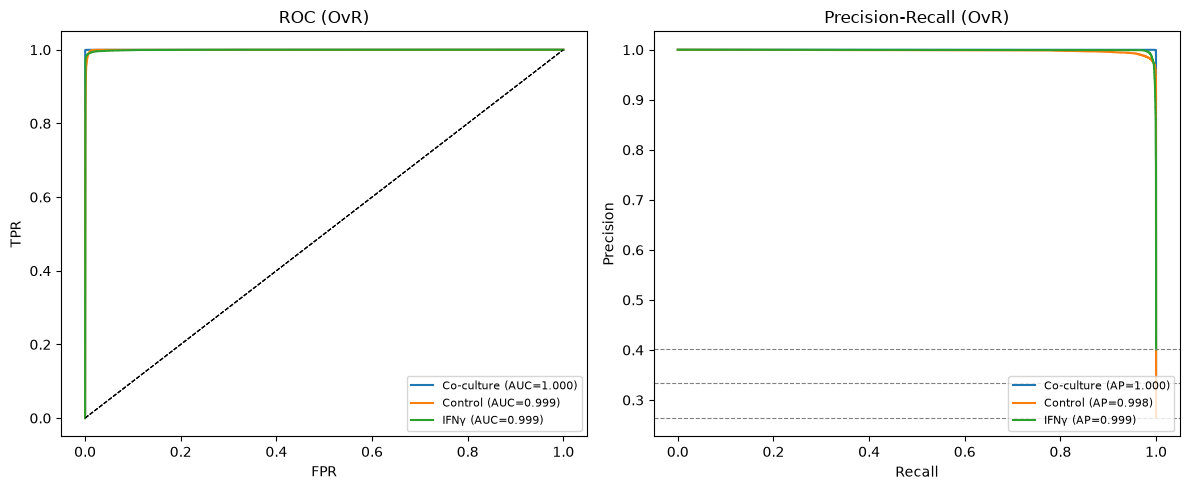

WARS               0.435
CD74               0.384
STAT1              0.383
HLA-B              0.372
GBP1               0.360
UBE2L6             0.349
B2M                0.337
TAP1               0.332
HLA-E              0.329
IDO1               0.319
HLA-DRB1           0.316
PSMB8              0.316
IRF1               0.306
PFN1               0.305
HLA-A              0.302
HLA-DRA            0.299
LAP3               0.295
PSMB9              0.289
RPL27A             0.280
GBP2               0.277


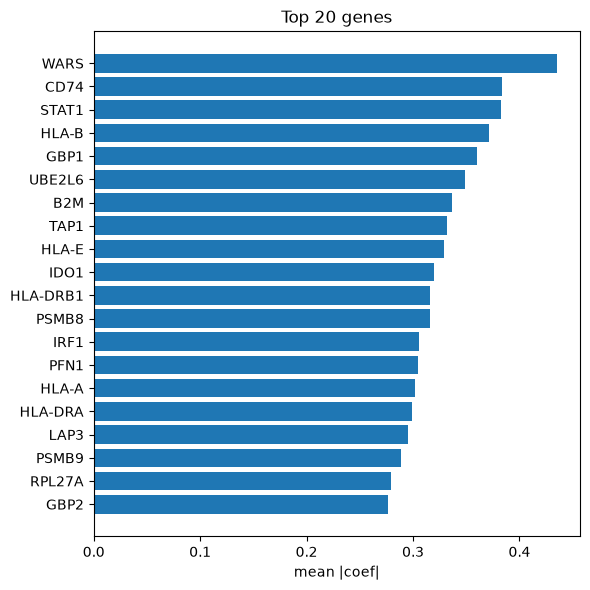

In [ ]:
# Logistic Regression - with all Genes

# Separate features from labels
X = adata.X
y = adata.obs["perturbation_2"].to_numpy()

# Model setup
lr = make_pipeline(
    StandardScaler(with_mean=False), # z = x / s; mean centering would blow up the sparse mtx by filling in zeros
    LogisticRegression(max_iter=2000, class_weight="balanced")
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_res = cross_validate( # more detailed than cross_val_score (see lecture)
    lr, 
    X_train, 
    y_train, 
    cv=cv,
    scoring=["balanced_accuracy", "roc_auc_ovr"],
    n_jobs=2,
)
for metric in ["test_balanced_accuracy", "test_roc_auc_ovr"]:
    scores = cv_res[metric]
    print(f"{metric[5:]:18s}: {scores.mean():.3f} +/- {scores.std():.3f}")
    print(f"\tFold scores: {[f'{x:.3f}' for x in scores]}")

# Train
lr.fit(X_train, y_train)
print(f"Interations until convergence: {lr.named_steps["logisticregression"].n_iter_}")

# Evaluation
evaluate(lr, X_test, y_test, adata.var_names)

After training the initial model, I tried training the same model with just the HVGs. Using not just HVGs, but all genes shows slightly better performance and is computaionally very managable for this type of model, so I will use this the model trained on all genes for further analysis.

/home/benjamin/Code/miniconda3/envs/final_project/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/benjamin/Code/miniconda3/envs/final_project/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/benjamin/Code/miniconda3/envs/final_project/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/benjamin/Code/miniconda3/envs/final_project/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/benjamin/Code/miniconda3/envs/final_project/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_ite

Best C: 0.1
Best solver: lbfgs
Best CV balanced accuracy: 0.988
C = 0.1  	solver = lbfgs 	0.988 +/- 0.000
C = 0.1  	solver = saga  	0.987 +/- 0.000
C = 1.0  	solver = lbfgs 	0.987 +/- 0.000
C = 1.0  	solver = saga  	0.987 +/- 0.000
C = 10.0 	solver = lbfgs 	0.987 +/- 0.000
C = 10.0 	solver = saga  	0.987 +/- 0.000
Iterations until convergence: [136]
accuracy          : 0.987
balanced acc.     : 0.988
macro AUROC (OvR) : 0.998
macro AUCPR (OvR) : 0.992

              precision    recall  f1-score   support

  Co-culture      0.997     0.997     0.997     14623
     Control      0.966     0.990     0.978     11526
        IFNγ      0.993     0.977     0.985     17518

    accuracy                          0.987     43667
   macro avg      0.985     0.988     0.986     43667
weighted avg      0.987     0.987     0.987     43667



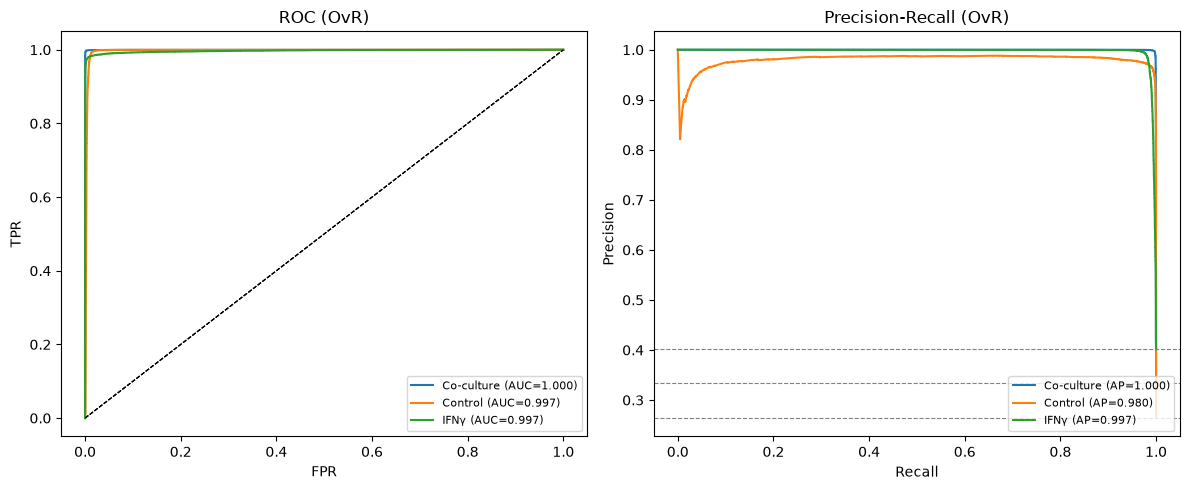

IDO1               1.526
CD74               0.852
WARS               0.817
CXCL10             0.695
PFN1               0.686
HLA-B              0.685
CXCL11             0.677
GBP1               0.615
HLA-DRA            0.595
FN1                0.547
PTGES              0.534
GBP4               0.488
B2M                0.484
HLA-DRB1           0.476
MTRNR2L12          0.456
GBP2               0.429
CXCL9              0.410
TUBA1B             0.389
HAPLN3             0.387
ETV7               0.386


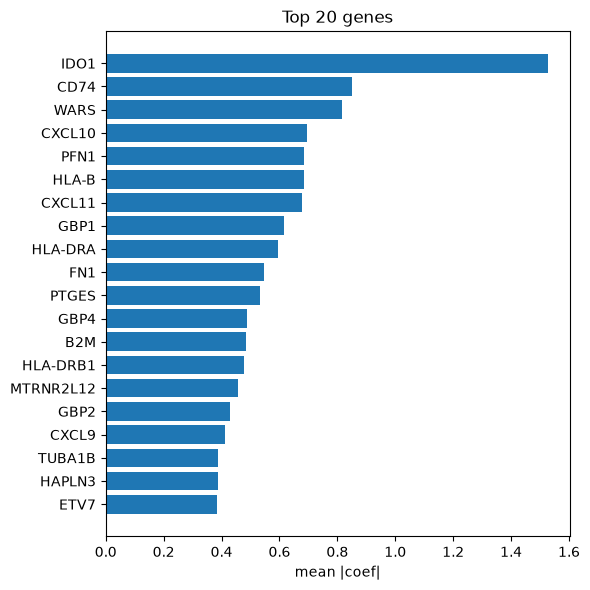

In [4]:
# Logistic Regression - with HVG and Grid Search

from sklearn.model_selection import GridSearchCV

# Hyperparameters - test different ones to fine-tune the model
lr_params = { 
    "logisticregression__C": [0.1, 1, 10],
    "logisticregression__solver": ["lbfgs", "saga"]
}

# Separate features from labels
X = HVG_adata.X
y = HVG_adata.obs["perturbation_2"].to_numpy()

# Model setup
lr = make_pipeline(
    StandardScaler(with_mean=False), # z = x / s; mean centering would blow up the sparse mtx by filling in zeros
    LogisticRegression(max_iter=1000, class_weight="balanced")
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    lr,
    param_grid=lr_params,
    cv=cv,
    scoring="balanced_accuracy",
    n_jobs=1,
    return_train_score=True
)

# Train
grid.fit(X_train, y_train)

# (short) Grid search evaluation 
print(f"Best C: {grid.best_params_["logisticregression__C"]}")
print(f"Best solver: {grid.best_params_["logisticregression__solver"]}")
print(f"Best CV balanced accuracy: {grid.best_score_:.3f}")

for C, solver, mean, std in zip(
    grid.cv_results_["param_logisticregression__C"],
    grid.cv_results_["param_logisticregression__solver"],
    grid.cv_results_["mean_test_score"],
    grid.cv_results_["std_test_score"]
):
    print(f"C = {C:<5}\tsolver = {solver:<6}\t{mean:.3f} +/- {std:.3f}")

# Best model evaluation
best_lr = grid.best_estimator_
print(f"Iterations until convergence: {best_lr.named_steps["logisticregression"].n_iter_}")

evaluate(best_lr, X_test, y_test, HVG_adata.var_names)

## 1.2. Driving Genes
**Task**: Identify the genes driving the separation \
**Approach**: 

,name,p_value,intersection_size,term_size
10,immune system process,1.113908e-07,16,2251
13,immune response,4.026052e-07,14,1540
50,defense response,2.313906e-04,12,1555
33,response to biotic stimulus,3.907574e-05,12,1332
37,regulation of immune system process,6.878938e-05,12,1399
30,response to external biotic stimulus,2.797421e-05,12,1294
29,response to other organism,2.747862e-05,12,1292
42,biological process involved in interspecies in...,9.978776e-05,12,1445
83,response to external stimulus,4.569982e-03,12,2023
15,positive regulation of immune response,6.213832e-07,11,684


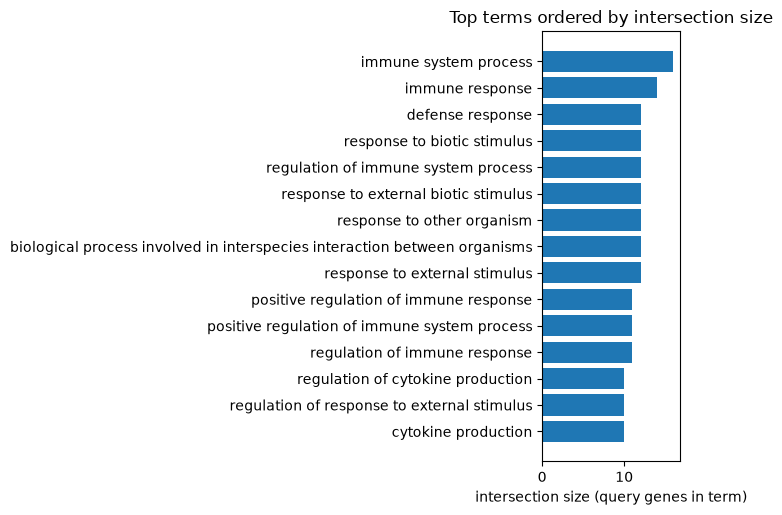

In [5]:
# GO term enrichment of the top 20 genes
from gprofiler import GProfiler

top_genes = [
    "WARS",
    "CD74",
    "STAT1",
    "HLA-B",
    "GBP1",
    "UBE2L6",
    "B2M",
    "TAP1",
    "HLA-E",
    "IDO1",
    "HLA-DRB1",
    "PSMB8",
    "IRF1",
    "PFN1",
    "HLA-A",
    "HLA-DRA",
    "LAP3",
    "PSMB9",
    "RPL27A",
    "GBP2"
]

# GO term annotation
gp = GProfiler(return_dataframe=True)
GO_res = gp.profile(
    organism="hsapiens",
    query = top_genes,
    sources=["GO:BP", "GO:MF"], # biological process & molecular function
    background=adata.var_names.tolist(),
    user_threshold=0.05
)

top_go = GO_res.sort_values("intersection_size", ascending=False).head(15)
display(top_go[["name", "p_value", "intersection_size", "term_size"]])

# GO plots
plt.figure(figsize=(7, len(top_go) * 0.35))
plt.barh(top_go["name"][::-1], top_go["intersection_size"][::-1])
plt.xlabel("intersection size (query genes in term)")
plt.title("Top terms ordered by intersection size")
plt.tight_layout()
plt.show()

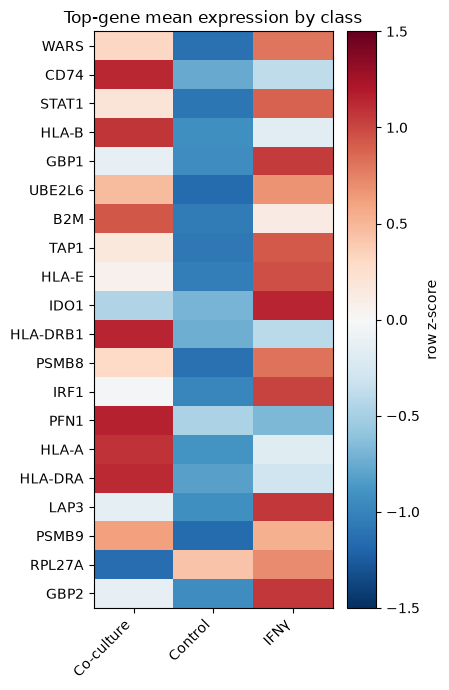

In [6]:
# Analyse expression change direction for genes of each class

genes = [g for g in top_genes if g in adata.var_names]
sub = adata[:, genes].X
sub = sub.toarray() if sparse.issparse(sub) else np.asarray(sub)

expr = pd.DataFrame(sub, columns=genes)
expr["class"] = adata.obs["perturbation_2"].to_numpy()

# mean expression per class, genes as rows
mean_tbl = expr.groupby("class").mean().T
mean_tbl = mean_tbl.loc[genes]        # keep ranked gene order

# z-score each gene across the 3 classes (color indicating relative change)
z = mean_tbl.sub(mean_tbl.mean(1), axis=0).div(mean_tbl.std(1) + 1e-9, axis=0)

fig, ax = plt.subplots(figsize=(4.5, len(genes) * 0.35))
im = ax.imshow(z, cmap="RdBu_r", aspect="auto", vmin=-1.5, vmax=1.5)

ax.set_xticks(range(z.shape[1]))
ax.set_xticklabels(z.columns, rotation=45, ha="right")
ax.set_yticks(range(len(genes)))
ax.set_yticklabels(genes)
fig.colorbar(im, ax=ax, label="row z-score")
ax.set_title("Top-gene mean expression by class")

plt.tight_layout()
plt.show()

### Discussion
A classifier can very well identify which treatment condition a cell came from given its gene expression profile. 

**Metrics Choice** \
For the cross-validation, Balanced Accuracy (= $\frac{\text{Recall}{INF\gamma} + \text{Recall}{Co-culture} + \text{Recall}_{Control}}{3}$) and ROC-AUC (area under the $\text{TPR}=\frac{TP}{TP + FN}$ vs $\text{FPR}=\frac{FP}{FP + TN}$ curve) were chosen, capturing both how well the three conditions are predicted on average and how well the model's prediction scores separate the classes across different classification thresholds. Furthermore, the final trained model uses a set of additional evaluation metrics, such as F1-score and PR curve to get even deeper insights into the model's performance. \

I deliberately chose these very standard metrics as they work well in this case, due to the classification task being fairly simple with just three, relatively balanced classes. For more complex, e.g. very unbalanced, datasets, it would be worth considering other problem-specific metrics, such as MCC, which I, however, do not deem to be necessary here.

**Model Performance** \
The results show an average Balanced Accuracy of 0.993 and ROC-AUC of 1 across different folds, meaning the model performs very well, leaving very little room for improvement. The same excellent performance can be seen when looking at the final trained model, showing again a nearly perfect ROC-AUC and PR-AUC of above 0.99 for all of the classes in the OvR case. Additionally, F1-scores are all above 0.98 as well, with the Co-culture score even reaching 0.999. As mentioned before, looking at the pretty large and fairly balanced dataset and the relatively simple task of distinguishing the three classes, I think Logistic Regression is the most reasonable model choice here and performs very well. I am sure taking a more complex model or doing thorough hyperparameter optimization would be able to increase the performance a bit further, but the trade-off in interpretability and computational cost makes it not worth it in my eyes.

**Feature Importance and Biological Context** \
Inspecting the features the model most heavily relied on for the classification, the most important gene seems to be WARS, closely followed by CD74 and STAT1. WARS is a gene which encodes for Tryptophanyl-tRNA synthetase and catalyzes the aminoacylation of tRNA Trp with tryptophan [$^1$](https://www.genecards.org/card/WARS1?search=WARS), and is also strongly upregulated in response to IFN-$\gamma$ expression [$^2$](https://pubmed.ncbi.nlm.nih.gov/8496617/). The genes with the second and third highest importance, CD74 and STAT1, are also highly involved in immune processes. While CD74 acts as a cell surface receptor and links antigen presentation with immune signaling, STAT1 encodes a transcription factor that transduces cytokine and growth factor signals [$^3$](https://www.genecards.org/search/results?q=STAT1), [$^4$](https://www.genecards.org/search/results?q=CD74). \
Taking into account that the experimental design was set up to induce effects in the interferon-$\gamma$ (IFN-$\gamma$)-JAK/STAT and antigen-presentation pathways, we can see that most genes in the top 20 belong to the IFN-$\gamma$-JAK/STAT pathway. These genes include core components such as STAT1, target genes including IRF1, GBP1 and GBP2, as well as many more broadly associated genes like PSMB8/9 and many of the HLA genes. Additionally, many genes are also class I MHCs (e.g. HLA-A, HLA-B or B2M) or involved in their processing (e.g. TAP1, PSMB8/9). Showing very much what would be expected as the most important genes based on the experimental setup.

Supporting GO term enrichment of the top 20 most important genes shows that all of the 15 terms with a significance above the 5% threshold are either directly or indirectly related to the immune system. Moreover, comparing the average expression of the top 20 genes for the three classes, it becomes clearly visible how the model is able to distinguish the three classes. While the control shows comparatively low expression for all of these genes, most of these genes are much more upregulated in the cells treated with IFN-$\gamma$ or that grew in co-culture cells, as both conditions activate immune responses in the cells. The difference, however, is that the IFN-$\gamma$ cells activate the IFN-$\gamma$-JAK/STAT pathway genes more (e.g. STAT1, IRF1), while the TIL in the co-culture leads to increased expression in MHC-I and antigen-presentation genes (e.g. HLA-A, HLA-B, B2M, TAP1, PSMB8/9), which is expected given they are needed for tumor-cell recognition by CD8⁺ T cells.

Much more analysis could be done on this part, but I will stop this here to go on to the other tasks.